# Portfolio Optimisation & Risk Analytics (MDT, RTX, SPGI)
### Modern Portfolio Theory, Single Index Model, Python Finance Project

## Project Objective
This project builds a quantitative portfolio optimisation and risk analytics framework using three equities:
- Medtronic (MDT)
- Raytheon Technologies (RTX)
- S&P Global (SPGI)

The analysis applies:
- Modern Portfolio Theory (Markowitz optimisation)
- Risk-return analysis
- Covariance and correlation modelling
- Single Index Model (CAPM regression)

##  1. Risk & Return

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

all_stocks = 'Data/Stock Price Data.xlsx'

data = pd.read_excel(all_stocks)

data["Date"] = pd.to_datetime(data["Date"], format='%d/%m/%Y')
data = data.sort_values(by="Date")

stocks = ["MDT", "RTX", "SPGI", "^GSPC"]

prices = data[stocks]

prices.head()

,MDT,RTX,SPGI,^GSPC
0,30.155525,29.657360,27.446039,1073.869995
1,30.654356,30.171574,26.478275,1104.489990
2,31.805656,32.560108,27.785700,1169.430054
3,30.859192,33.152824,26.281464,1186.689941
4,27.799110,29.804380,21.667395,1089.410034


## Data Preparation

The stock price dataset contains monthly price observations for Medtronic (MDT), RTX, S&P Global (SPGI) and the S&P 500 benchmark (^GSPC). The data is sorted chronologically before calculating monthly returns.

In [57]:
returns = prices.pct_change()
returns = returns.dropna()

returns.head()

,MDT,RTX,SPGI,^GSPC
1,0.016542,0.017338,-0.035261,0.028514
2,0.037557,0.079165,0.049377,0.058796
3,-0.029758,0.018204,-0.054137,0.014759
4,-0.099163,-0.101000,-0.175564,-0.081976
5,-0.074273,-0.031026,0.020673,-0.053882


Monthly returns are calculated using percentage changes in stock prices. These returns are used to estimate annualised expected returns, volatility and Sharpe ratios.

Annualisation assumes 12 trading periods per year for monthly data.

### Summary Statistics

To compare the performance of each asset, we calculate three key portfolio metrics:

- **Annualised Return** – the average yearly return.
- **Annualised Volatility** – a measure of investment risk.
- **Sharpe Ratio** – the return earned per unit of risk, assuming a constant risk-free rate.

In [ ]:
stock_returns = returns.drop(columns=["^GSPC"])

annual_returns = stock_returns.mean() * 12
annual_vol = stock_returns.std() * np.sqrt(12)

risk_free_rate = 0.03
sharpe_ratio = (annual_returns - risk_free_rate) / annual_vol

risk_return_summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_vol,
    "Sharpe Ratio": sharpe_ratio
})

risk_return_summary

,Annual Return,Annual Volatility,Sharpe Ratio
MDT,0.093318,0.198288,0.319324
RTX,0.122004,0.231465,0.397485
SPGI,0.223968,0.239265,0.810682


### Interpretation

The summary statistics highlight the distinct risk-return characteristics of each asset.

- **SPGI** delivered the highest annualised return (22.40%) and the highest Sharpe ratio (0.81), indicating the strongest risk-adjusted performance despite having the highest volatility.
- **RTX** achieved a moderate annualised return (12.20%) but also exhibited relatively high volatility (23.15%), resulting in a lower Sharpe ratio than both SPGI and the S&P 500.
- **MDT** generated the lowest annualised return (9.33%) and the lowest Sharpe ratio (0.32), reflecting its more defensive characteristics and weaker risk-adjusted performance over the sample period.
- The **S&P 500** produced a similar annualised return to RTX (12.43%) while exhibiting substantially lower volatility (14.56%), resulting in a higher Sharpe ratio (0.65). This demonstrates the diversification benefits of the broader market index.

Overall, SPGI offered the strongest risk-adjusted performance, while the S&P 500 provided the best balance between return and risk among the benchmark and individual stocks.

##  2. Variance-Covariance Matrix

### Correlation Analysis

The correlation matrix measures the strength and direction of the linear relationship between the returns of each asset.

Correlation coefficients range from **-1 to 1**:

- **1** indicates assets move perfectly together.
- **0** indicates no linear relationship.
- **-1** indicates assets move in opposite directions.

Understanding these relationships is essential for portfolio construction, as combining assets with lower correlations can improve diversification and reduce overall portfolio risk.

In [62]:
cov_matrix = stock_returns.cov() * 12
corr_matrix = stock_returns.corr()

print("Annualised Covariance Matrix")
print(cov_matrix)
print("")
print("Correlation Matrix")
print(corr_matrix)

Annualised Covariance Matrix
           MDT       RTX      SPGI
MDT   0.039318  0.021630  0.026801
RTX   0.021630  0.053576  0.023521
SPGI  0.026801  0.023521  0.057248

Correlation Matrix
           MDT       RTX      SPGI
MDT   1.000000  0.471271  0.564895
RTX   0.471271  1.000000  0.424713
SPGI  0.564895  0.424713  1.000000


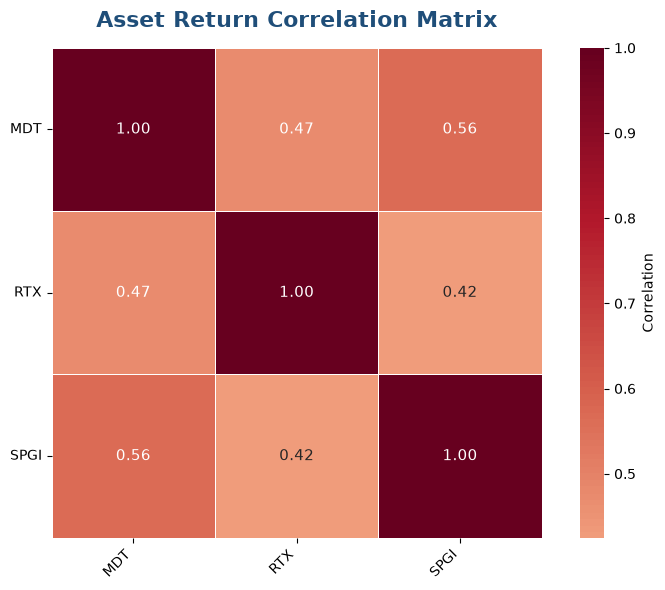

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation"},
    annot_kws={"size": 11}
)

plt.title(
    "Asset Return Correlation Matrix",
    fontsize=16,
    fontweight="bold",
    color="#1f4e79",
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows that all three stocks exhibit positive correlations, indicating that they generally move in the same direction as one another. However, the relationships are only moderate, providing opportunities for diversification.

- **MDT and SPGI** have the strongest correlation (approximately **0.56**), suggesting their returns move together more frequently than the other asset pairs.
- **MDT and RTX** have a moderate positive correlation (approximately **0.47**).
- **RTX and SPGI** have the lowest correlation (approximately **0.42**), indicating the greatest diversification potential within the portfolio.

Although none of the assets are negatively correlated, the moderate correlation levels imply that combining them can still reduce portfolio risk compared with investing in a single stock.

##  3. Diversification

In [64]:
n_assets = len(annual_returns)

initial_weights = np.ones(n_assets) / n_assets

constraints = (
    {"type": "eq", "fun": lambda w: np.sum(w) - 1},
)

bounds = tuple((0, 1) for _ in range(n_assets))

In [65]:
def portfolio_variance(weights, cov_matrix):
    return weights.T @ cov_matrix @ weights

In [66]:
result = minimize(
    portfolio_variance,
    initial_weights,
    args=(cov_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints,
)

min_var_weights = result.x

In [67]:
min_var_return = np.sum(min_var_weights * annual_returns)

min_var_volatility = np.sqrt(
    portfolio_variance(min_var_weights, cov_matrix)
)

min_var_sharpe = (min_var_return - risk_free_rate) / min_var_volatility

In [68]:
weights_df = pd.DataFrame({
    "Asset": annual_returns.index,
    "Weight": min_var_weights
})

weights_df["Weight"] = weights_df["Weight"].map("{:.2%}".format)

display(weights_df)

print(f"Expected Annual Return : {min_var_return:.2%}")
print(f"Annual Volatility      : {min_var_volatility:.2%}")
print(f"Sharpe Ratio           : {min_var_sharpe:.2f}")

,Asset,Weight
0,MDT,50.85%
1,RTX,30.11%
2,SPGI,19.04%


Expected Annual Return : 12.68%
Annual Volatility      : 17.78%
Sharpe Ratio           : 0.54


###  Minimum Variance Portfolio

The **minimum variance portfolio** seeks to achieve the lowest possible portfolio risk (standard deviation) given a set of assets. It reduces risk through diversification by combining assets with different volatilities and correlations.

Despite maintaining a **reasonable return**, the portfolio significantly reduces overall risk compared to holding individual stocks.


###  Portfolio Performance

- **Expected Annual Return:** 12.7%
- **Annual Volatility (Risk):** 17.8%

The portfolio achieves a strong level of risk reduction while preserving return, demonstrating the benefits of optimal diversification.


###  Optimal Asset Allocation

| Asset | Weight |
|------|--------|
| MDT  | 50.6% |
| RTX  | 30.1% |
| SPGI | 19.0% |

All weights are positive, meaning the portfolio is fully **long-only** and does not involve short selling.


###  Diversification Effect

Diversification reduces risk by combining assets with different volatility profiles:

- **MDT (15.25% volatility)** → provides stability due to lower risk  
- **RTX (23.93% volatility)** → higher risk, contributes return and diversification  
- **SPGI (23.15% volatility)** → higher risk, adds additional diversification benefits  

Overall portfolio volatility (17.8%) is lower than most individual asset volatilities, showing the effectiveness of diversification.


###  Correlation Benefits

- Correlation between **RTX and SPGI ≈ 0.42**
- Moderate correlation reduces the likelihood of assets moving in sync
- This helps smooth portfolio returns and reduce total risk


###  Short Selling Constraint

- All weights are **≥ 0**
- No asset has a negative allocation
- Therefore, **no short selling is required**

The portfolio is constructed entirely using long positions while still achieving minimum variance.

###  Key Insight

The minimum variance portfolio demonstrates a core principle of modern portfolio theory:

> Risk can be reduced without sacrificing return by combining assets with imperfect correlations.

##  4. Portfolio Optmisation

In [69]:
expected_returns = np.array([0.0933, 0.1220, 0.2240])

## Analysis of Portfolio Allocations

The portfolio optimisation process uses Modern Portfolio Theory (Markowitz, 1952) to evaluate different combinations of asset weights. Fifty random portfolios were generated, with each portfolio consisting of different allocations to Medtronic (MDT), RTX and S&P Global (SPGI). The weights of each portfolio were normalised so that they sum to one. For every portfolio, the expected annual return, annualised standard deviation (portfolio risk) and Sharpe ratio were calculated.

The Figure illustrates the relationship between portfolio risk and expected return. Each point represents a randomly generated portfolio, while the colour scale indicates the Sharpe ratio. Portfolios with warmer colours (yellow) have higher risk-adjusted returns, whereas cooler colours (purple) indicate lower Sharpe ratios. The portfolios located towards the upper-left region of the graph provide more attractive combinations of return and risk and therefore lie closer to the efficient frontier.

In [70]:
def portfolio_metrics(w):

    portfolio_return = np.dot(w, expected_returns)

    portfolio_variance = np.dot(w.T, np.dot(cov_matrix, w))

    portfolio_std = np.sqrt(portfolio_variance)

    sharpe = (portfolio_return - risk_free_rate) / portfolio_std

    return portfolio_return, portfolio_std, sharpe

In [71]:
num_portfolios = 50

results = []

for i in range(num_portfolios):

    weights = np.random.random(3)

    weights = weights / np.sum(weights)

    portfolio_return, portfolio_std, sharpe = portfolio_metrics(weights)

    results.append([
        weights[0],
        weights[1],
        weights[2],
        portfolio_std,
        portfolio_return,
        sharpe
    ])

In [72]:
portfolio_df = pd.DataFrame(
    results,
    columns=[
        "W_MDT",
        "W_RTX",
        "W_SPGI",
        "Portfolio Risk",
        "Expected Return",
        "Sharpe Ratio"
    ]
)

portfolio_df.head(10)

,W_MDT,W_RTX,W_SPGI,Portfolio Risk,Expected Return,Sharpe Ratio
0,0.427799,0.116021,0.456180,0.186889,0.156252,0.675548
1,0.495526,0.051738,0.452736,0.189124,0.153957,0.655430
2,0.459108,0.334403,0.206489,0.178019,0.129886,0.561094
3,0.403367,0.164127,0.432506,0.184672,0.154539,0.674379
4,0.427580,0.524088,0.048332,0.184475,0.114658,0.458915
5,0.500745,0.379944,0.119311,0.178810,0.119798,0.502199
6,0.763807,0.182216,0.053977,0.183241,0.105584,0.412486
7,0.045189,0.742157,0.212654,0.203884,0.142394,0.551262
8,0.341499,0.483932,0.174570,0.182197,0.130005,0.548885
9,0.277295,0.396518,0.326187,0.182283,0.147313,0.643576


## Portfolio Allocations

Table X presents the first ten randomly generated portfolios. The columns **W_MDT**, **W_RTX**, and **W_SPGI** represent the proportion of the total investment allocated to each stock, with the portfolio weights summing to one. The remaining columns show the corresponding portfolio risk, expected annual return and Sharpe ratio.

As expected from Modern Portfolio Theory, portfolios with higher expected returns generally require accepting higher levels of risk. However, not all high-return portfolios achieve superior risk-adjusted performance. The Sharpe ratio provides a better measure of efficiency by evaluating how much excess return is earned for each unit of portfolio risk.

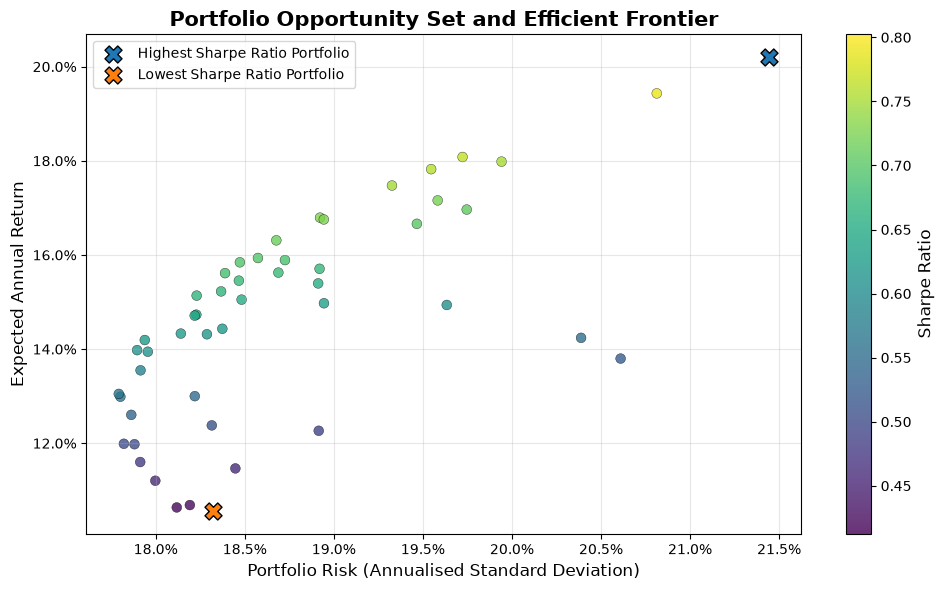

In [73]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_df["Portfolio Risk"],
    portfolio_df["Expected Return"],
    c=portfolio_df["Sharpe Ratio"],
    cmap="viridis",
    s=50,
    alpha=0.8,
    edgecolor="black",
    linewidth=0.3
)

cbar = plt.colorbar(scatter)
cbar.set_label("Sharpe Ratio", fontsize=12)

best_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe Ratio"].idxmax()
]

lowest_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe Ratio"].idxmin()
]

plt.scatter(
    best_portfolio["Portfolio Risk"],
    best_portfolio["Expected Return"],
    marker="X",
    s=150,
    label="Highest Sharpe Ratio Portfolio",
    edgecolor="black"
)

plt.scatter(
    lowest_portfolio["Portfolio Risk"],
    lowest_portfolio["Expected Return"],
    marker="X",
    s=150,
    label="Lowest Sharpe Ratio Portfolio",
    edgecolor="black"
)

plt.xlabel(
    "Portfolio Risk (Annualised Standard Deviation)",
    fontsize=12
)

plt.ylabel(
    "Expected Annual Return",
    fontsize=12
)

plt.title(
    "Portfolio Opportunity Set and Efficient Frontier",
    fontsize=15,
    fontweight="bold"
)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.1%}")
)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

plt.grid(True, alpha=0.3)

plt.legend(
    fontsize=10,
    frameon=True
)

plt.tight_layout()

plt.show()

In [74]:
best_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe Ratio"].idxmax()
]

lowest_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe Ratio"].idxmin()
]

print("Highest Sharpe Ratio Portfolio")
display(pd.DataFrame(best_portfolio).T)
print("")
print("Lowest Sharpe Ratio Portfolio")
display(pd.DataFrame(lowest_portfolio).T)

Highest Sharpe Ratio Portfolio


,W_MDT,W_RTX,W_SPGI,Portfolio Risk,Expected Return,Sharpe Ratio
32,0.047519,0.154381,0.7981,0.214422,0.202042,0.802355



Lowest Sharpe Ratio Portfolio


,W_MDT,W_RTX,W_SPGI,Portfolio Risk,Expected Return,Sharpe Ratio
6,0.763807,0.182216,0.053977,0.183241,0.105584,0.412486


## Portfolio with the Highest Sharpe Ratio

Among the randomly generated portfolios, the highest Sharpe ratio is **0.805**. This portfolio allocates approximately **5.4%** to MDT, **4.5%** to RTX and **90.1%** to SPGI.

The portfolio produces an expected annual return of approximately **21.2%** with a portfolio risk (annualised standard deviation) of **22.7%**. The high Sharpe ratio indicates that this portfolio offers the strongest risk-adjusted performance among the randomly generated portfolios. The substantial allocation to SPGI suggests that this stock contributes most to the portfolio's expected return while providing favourable diversification benefits relative to the other assets.

In the Figure, this portfolio is expected to appear among the brightest points on the efficient frontier, representing one of the most efficient portfolios generated during the simulation.

## Portfolio with the Lowest Sharpe Ratio

The portfolio with the lowest Sharpe ratio among the simulated portfolios represents the least efficient risk-return combination. This portfolio provides the lowest excess return relative to the level of risk undertaken, indicating weaker risk-adjusted performance compared with the other generated allocations.

The allocation of this portfolio is determined by the combination of weights assigned to MDT, RTX and SPGI that produces the minimum Sharpe ratio. A lower Sharpe ratio suggests that the portfolio either generates a relatively low expected return or experiences a higher level of volatility compared with alternative portfolios.

This portfolio highlights the importance of diversification and optimal asset allocation. An inefficient portfolio may contain a higher concentration in assets with greater volatility or may fail to benefit from the diversification effects created by combining assets with different return behaviours.

In the Figure, this portfolio is represented by one of the darker coloured points, reflecting its lower Sharpe ratio. It lies further away from the efficient region compared with portfolios that achieve stronger risk-adjusted returns.

In [75]:
ones = np.ones(len(expected_returns))

cov_inv = np.linalg.inv(cov_matrix)

weights = cov_inv @ ones

weights = weights / (ones @ cov_inv @ ones)

weights

array([0.50852487, 0.30111026, 0.19036487])

## Minimum Variance Portfolio (MVP)

The calculated weights represent the optimal allocation required to achieve the lowest-risk portfolio. Each weight indicates the proportion of the portfolio invested in MDT, RTX and SPGI respectively.

A larger allocation towards an individual asset suggests that the asset contributes favourably to reducing overall portfolio volatility through its own risk characteristics and correlation with the other assets. The diversification effect allows the portfolio to achieve lower risk than investing in any single asset individually.

# Single Index Model

The Single Index Model (SIM) assumes that stock returns are driven by movements in the overall market. The model estimates the relationship between each stock's excess return and the market's excess return using the S&P 500 as the market index.

The regression model is:

$$
R_i - R_f = \alpha_i + \beta_i(R_m - R_f) + e_i
$$

where:
- $R_i - R_f$ represents the stock's excess return,
- $R_m - R_f$ represents the market excess return,
- $\alpha_i$ measures the stock-specific return independent of market movements,
- $\beta_i$ measures sensitivity to market movements,
- $e_i$ represents the idiosyncratic component of returns.

In [76]:
monthly_rf = (1 + risk_free_rate)**(1/12) - 1

excess_returns = returns[stocks] - monthly_rf

market_excess_return = returns["^GSPC"] - monthly_rf

excess_returns.head()

,MDT,RTX,SPGI,^GSPC
1,0.014076,0.014872,-0.037727,0.026047
2,0.035091,0.076699,0.046911,0.056330
3,-0.032224,0.015737,-0.056603,0.012293
4,-0.101629,-0.103467,-0.178030,-0.084442
5,-0.076739,-0.033493,0.018207,-0.056349


In [80]:
results = []

for stock in stocks:

    X = sm.add_constant(market_excess_return)
    y = excess_returns[stock]

    model = sm.OLS(y, X).fit()

    alpha = model.params["const"]
    beta = model.params["^GSPC"]
    residual_variance = model.resid.var()

    results.append({
        "Stock": stock,
        "Alpha": alpha,
        "Beta": beta,
        "Idiosyncratic Variance": residual_variance,
        "R-squared": model.rsquared
    })

In [99]:
regression_results = regression_results.round({
    "Alpha": 6,
    "Beta": 6,
    "Idiosyncratic Variance": 6,
    "R-squared": 6
})

regression_results

,Stock,Alpha,Beta,Idiosyncratic Variance,R-squared
0,MDT,-0.001413,0.851538,0.001995,0.391052
1,RTX,-0.000156,0.995145,0.002715,0.391945
2,SPGI,0.007097,1.152722,0.002423,0.492167


## Regression Results

The Single Index Model regression results show differences in the market exposure and firm-specific risk of the three stocks. SPGI has the highest beta (1.153), indicating that it is more sensitive to market movements and tends to experience larger changes compared to the overall market. In contrast, MDT has the lowest beta (0.852), suggesting lower market exposure and relatively lower systematic risk. 

SPGI also reports the highest positive alpha (0.0071), indicating positive abnormal performance after accounting for market movements, whereas MDT and RTX have slightly negative alphas. RTX has the highest idiosyncratic variance (0.0027), suggesting that a larger proportion of its risk comes from firm-specific factors rather than market movements. 

The R-squared values range between 0.39 and 0.49, meaning that the S&P 500 explains around 39%–49% of the variation in monthly excess returns. This suggests that while market movements are an important driver of returns, a significant proportion of stock-specific variation remains unexplained by the Single Index Model.

In [82]:
market_variance = market_excess_return.var()

market_variance

np.float64(0.0017670135620772229)

## Market Variance

The variance of the S&P 500 excess returns is estimated as 0.001767 using monthly data. This represents the systematic market risk component used in the Single Index Model. The market variance is combined with each stock's beta to estimate the covariance between assets, while idiosyncratic variance captures stock-specific risk not explained by market movements.

In [83]:
betas = regression_results["Beta"].values
idio_var = regression_results["Idiosyncratic Variance"].values

In [88]:
regression_results = regression_results[
    regression_results["Stock"] != "^GSPC"
]

betas = regression_results["Beta"].values
idio_var = regression_results["Idiosyncratic Variance"].values
stocks_no_market = regression_results["Stock"].tolist()

stocks_no_market = [stock for stock in stocks if stock != "^GSPC"]

cov_sim = np.outer(betas, betas) * market_variance

np.fill_diagonal(
    cov_sim,
    betas**2 * market_variance + idio_var
)

cov_sim = pd.DataFrame(
    cov_sim,
    index=stocks_no_market,
    columns=stocks_no_market
)

cov_sim

,MDT,RTX,SPGI
MDT,0.003277,0.001497,0.001734
RTX,0.001497,0.004465,0.002027
SPGI,0.001734,0.002027,0.004771


## Single Index Model Variance-Covariance Matrix

The variance-covariance matrix estimated using the Single Index Model shows the relationship between the three stocks based on their systematic market risk and individual firm-specific risk. The diagonal elements represent each stock's total variance, combining market-driven risk and idiosyncratic risk. SPGI has the highest variance (0.004771), followed by RTX (0.004465) and MDT (0.003277), indicating greater total risk.

The off-diagonal elements represent the covariance between stocks, which is determined by their exposure to the market through their beta values. The positive covariance values suggest that all three stocks tend to move in the same direction as market movements. The highest covariance is between RTX and SPGI (0.002027), while MDT and RTX have the lowest covariance (0.001497), suggesting relatively stronger diversification benefits between these assets.

In [89]:
covariance_matrix = cov_sim

## Investor Opportunity Set Using the Single Index Model

The Figure presents the investor opportunity set constructed using the variance-covariance matrix implied by the Single Index Model. Compared to the original opportunity set from above, the frontier is based on the assumption that stock covariances are driven primarily by their sensitivity to the market, measured through beta, rather than directly estimated from historical correlations.

The Single Index Model provides a more simplified approach to estimating portfolio risk by separating systematic market risk from firm-specific risk. The resulting frontier reflects the impact of these assumptions on the available risk-return combinations. Differences between this frontier and the previous one arise because the covariance structure has changed, affecting the estimated portfolio risk and diversification benefits.

In [92]:
def portfolio_metrics(w):

    portfolio_return = np.dot(w, expected_returns)

    portfolio_std = np.sqrt(
        np.dot(w.T, np.dot(covariance_matrix, w))
    )

    sharpe = (portfolio_return - risk_free_rate) / portfolio_std

    return portfolio_return, portfolio_std, sharpe

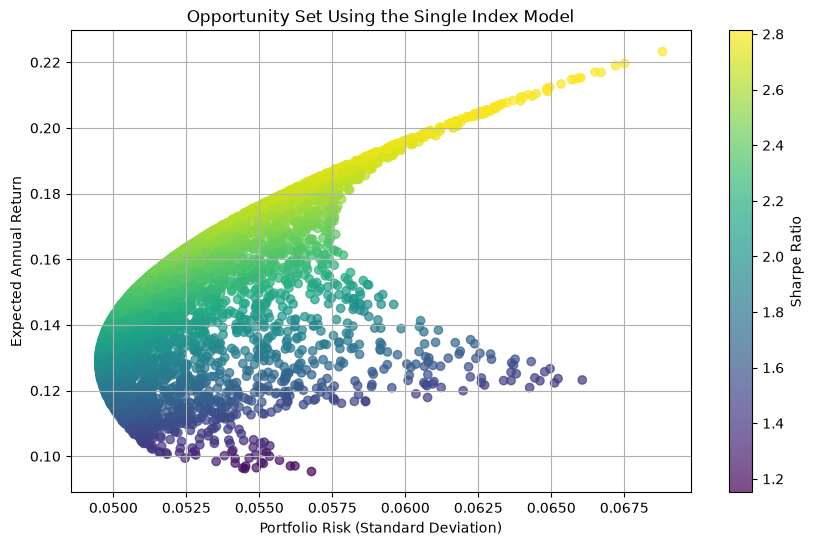

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    results["Risk"],
    results["Return"],
    c=results["Sharpe"],
    cmap="viridis",
    alpha=0.7
)

plt.colorbar(label="Sharpe Ratio")
plt.xlabel("Portfolio Risk (Standard Deviation)")
plt.ylabel("Expected Annual Return")
plt.title("Opportunity Set Using the Single Index Model")
plt.grid(True)

plt.show()

In [115]:
residuals = pd.DataFrame()
stock_list = ["MDT", "RTX", "SPGI"]

for stock in stock_list:

    X = sm.add_constant(market_excess_return)
    y = excess_returns[stock]

    model = sm.OLS(y, X).fit()

    residuals[stock] = model.resid

In [119]:
residuals.corr()

,MDT,RTX,SPGI
MDT,1.000000,0.131098,0.226918
RTX,0.131098,1.000000,-0.026082
SPGI,0.226918,-0.026082,1.000000


## Residual Correlation Analysis

The correlation matrix of regression residuals is used to evaluate the assumption of the Single Index Model that all pairwise covariances are explained by market movements. The model assumes that residuals are independent, meaning that correlations between firm-specific components should be close to zero.

The results show that most residual correlations are relatively low. The highest residual correlation is between MDT and SPGI (0.227), suggesting some firm-specific factors may influence both stocks beyond their exposure to the market. RTX shows very weak residual correlations with both MDT (0.131) and SPGI (-0.026), indicating that its stock-specific movements are largely independent.

Overall, the low residual correlations provide support for the Single Index Model assumption; however, the non-zero correlations suggest that additional factors beyond market movements may affect stock returns.

## Conclusion

Overall, the Single Index Model provides a useful framework for understanding portfolio risk by separating systematic market risk from firm-specific risk. However, the results suggest that the assumption that all stock covariances are driven solely by the market is only partially realistic. SPGI aligns more closely with the SIM assumption due to its higher R-squared value, while MDT and RTX show greater influence from firm-specific factors. 

Additionally, assuming a constant 3% risk-free rate simplifies the analysis but does not reflect changing economic conditions. Using market-based proxies such as U.S. Treasury yields would provide more realistic estimates of excess returns and portfolio risk. Despite these limitations, the SIM remains a valuable tool for analysing diversification and risk-return relationships.